<a href="https://colab.research.google.com/github/A-Kester/csci-451/blob/main/docs/live-notebooks/40-intro-deep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducing Deep Learning

Learn the features.

## The Problem of Features

An ongoing tension throughout our study of machine learning has been the need express nonlinear relationships between the features $\mathbf{x}_i$ and the target variable $y_i$ while maintaining a manageable model complexity. Models that don’t have the capacity to express nonlinear relationships (e.g. logistic regression without feature maps) will often underfit nonlinear data, but models that are *too* flexible (e.g. logistic regression with a high-dimensional feature map) will often overfit.

Our approach so far has been to study problems of the form

$$
\begin{aligned}
    {\color{blue}\hat{\mathbf{W}}} = \mathop{\mathrm{arg\,min}}_{{\color{blue}\mathbf{W}} \in \mathbb{R}^{d\times k}} \frac{1}{n}\sum_{i=1}^n \ell(\mathbf{\phi}(\mathbf{x}_i){\color{blue}\mathbf{W}}, y_i) + \lambda r({\color{blue}\mathbf{W}})\;,
\end{aligned}
 \qquad(1)$$

where:

-   $\mathbf{W}$ is a matrix of parameters that we are trying to learn, and $\hat{\mathbf{W}}$ is the optimal parameter vector that minimizes the objective function. In the context of regression we had $\mathbf{W}\in \mathbb{R}^{d\times1}$ where $d$ is the dimension of the feature map $\mathbf{\phi}(\mathbf{x}_i)$, while in the context of classification we had $\mathbf{W}\in \mathbb{R}^{k\times d}$ where $k$ is the number of classes and $d$ is again the dimension of the feature map.
-   $\mathbf{x}_i$ is the feature vector for the $i$-th training example, and $y_i$ is the corresponding label or target value.
-   $\mathbf{\phi}$ is an optional nonlinear *feature map* that maps the input features $\mathbf{x}_i$ to a higher-dimensional space, enabling us to learn nonlinear relationships between the features and the target variable.
-   $\ell$ is a loss function that measures the discrepancy between the predicted value \$ = (\_i)\$ and the true label $y_i$.
    -   In the context of regression we’ve seen $\ell(\hat{y},y) = (\hat{y}-y)^2$ (mean-squared error) and $\ell(\hat{y},y) = \lvert \hat{y}-y \rvert$ (mean-absolute error).
    -   In the context of classification we’ve seen $\ell(\hat{y},y) = y\log \sigma(\hat{y}) + (1-y)\log(1-\sigma(\hat{y}))$ (logistic loss).
-   $\lambda r({\color{blue}\mathbf{W}})$ is a regularization term that penalizes large values of the parameters $\mathbf{W}$ to guard against overfitting. We’ve seen examples of regularization terms such as $\lambda \|\mathbf{W}\|_2^2$ (L2 regularization) and $\lambda \|\mathbf{W}\|_1$ (L1 regularization).

### Too Many Features

One of the reasons this problem is difficult is that we don’t usually know at the outset *which* feature maps are likely to be helpful for our modeling problem. So, we often generate *many* features (e.g. all polynomials of degree up to $k$) and then hope that some of these will be helpful. Techniques like regularization or model selection via cross-validation can help us to avoid overfitting in this setting, but they don’t solve the problem of having to generate a large number of features in the first place.

### Motivating Representation Learning

Wouldn’t it be so much easier if our models could just *learn* which features are helpful for the problem? That is, what if we could instead solve a problem of the form

$$
\begin{aligned}
    {\color{blue}\hat{\mathbf{W}}}, {\color{red}\hat{\mathbf{\phi}}} = \mathop{\mathrm{arg\,min}}_{{\color{blue}\mathbf{W}} \in \mathbb{R}^{d\times k}, {\color{red}\mathbf{\phi}} \in \Phi} \frac{1}{n}\sum_{i=1}^n \ell(( {\color{red}\mathbf{\phi}}(\mathbf{x}_i){\color{blue}\mathbf{W}}), y_i) \;,
\end{aligned}
 \qquad(2)$$

where now we learn the feature map $\mathbf{\phi}$ rather than having to specify it in advance? If we think of a feature map $\mathbf{\phi}$ as a function that *represents* a data point $\mathbf{x}_i$ in some new way, then what we are asking for is a model that can learn how to represent data points in a way that facilitates prediction of the target variable. This problem is sometimes called *representation learning*, and is the primary motivation of deep learning.

## Interlude: Computational Graphs Again

To begin our study, it’s helpful to start moving beyond equations and into visual representations of our models. This is another setting in which the idea of a computational graph can be very helpful, although this time our graphs will be somewhat less detailed than when we studied automatic differentiation. In <a href="#eq-empirical-risk-minimization" class="quarto-xref">Equation 1</a>, ignoring the regularization term for simplicity, we can think of the model output \$\_i = (\_i)\$ as being generated by a computational graph that takes $\mathbf{x}_i$ as input, applies the feature map $\mathbf{\phi}$ to generate a new representation of the data point, and then applies a linear transformation (the multiplication with $\mathbf{W}$) to generate the output. Schematically, we can represent this process with the following diagram.

<figure id="fig-shallow-model">
<img src="attachment:fig/feature-learning-1.png" />
<figcaption>Figure 1: Example flow of data through a computational graph for a model of the form in <a href="#eq-empirical-risk-minimization" class="quarto-xref">Equation 1</a>. The bottom row shows the state of the data as it flows through the graph, while the top row shows the operations applied to the data to move from one stage to the next. The feature map <span class="math inline"><strong>ϕ</strong></span> is fixed and not learned by the model.</figcaption>
</figure>

An important feature of this model architecture is that the model weights $\mathbf{W}$ are *trainable*, but the feature map $\mathbf{\phi}$ is *not* trainable. This means that the model can learn to use the features generated by $\mathbf{\phi}$ in a way that minimizes the loss, but it cannot tune these features to be more helpful for the task at hand. To move beyond that limitation requires a model that attempts to solve <a href="#eq-representation-learning" class="quarto-xref">Equation 2</a>.

## Multilayer Perceptron

In general we can’t possibly choose “the best” feature map $\mathbf{\phi}$ from the space of all possible functions – there are too many choices for the optimization to be feasible. So, we typically restrict $\mathbf{\phi}$ to lie within some parameterized family of functions, which we then optimizer over. For our first model that uses representation learning, we’ll let $\mathbf{\phi}$ have the following two-stage structure:

1.  First, multiply $\mathbf{x}$ by a matrix $\mathbf{V}$ of learnable weights.
2.  Then, apply a fixed nonlinear function $\alpha$, called an *activation function*, entrywise to each element of the resulting vector.

Common choices of the activation function $\alpha$ include the sigmoid function $\alpha(z) = 1/(1+e^{-z})$ and the rectified linear unit (ReLU) function $\text{ReLU}(z) = \max(0,z)$.

The structure of our feature map is therefore

$$
\begin{aligned}
    \phi(\mathbf{x}) = \alpha(\mathbf{x}\mathbf{V})\;.
\end{aligned}
 \qquad(3)$$

The *input* dimension of the map must be $d$, the dimension of the original data $\mathbf{x}$. The *output* dimension of the feature map is tunable; let’s call it $p$. The matrix $\mathbf{V}$ therefore has dimensions $d \times p$.

<figure id="fig-one-hidden-layer">
<img src="attachment:fig/feature-learning-2.png" />
<figcaption>Figure 2: Example flow of data through a computational graph for a model with feature maps of the form <a href="#eq-mlp-feature-map" class="quarto-xref">Equation 3</a>. The feature map <span class="math inline"><strong>ϕ</strong></span> is now parameterized by the matrix <span class="math inline"><strong>V</strong></span>, which is learned by the model.</figcaption>
</figure>

Importantly, if $\mathbf{V}\in \mathbb{R}^{d \times p}$, then $\alpha(\mathbf{x}\mathbf{V}) \in \mathbb{R}^p$. This implies that the *next* matrix multiplication must have input dimension $p$ and output dimension $k$, where $k$ is the dimension of the final model output. In other words, we must have $\mathbf{W}\in \mathbb{R}^{p \times k}$, and the output of the model $\hat{y} = \alpha(\mathbf{x}\mathbf{V})\mathbf{W}\in \mathbb{R}^k$.

## Getting started with Deep Models in PyTorch

Let’s go ahead and start implementing these models in PyTorch. We’re going to *start* with the model illustrated in <a href="#fig-shallow-model" class="quarto-xref">Figure 1</a> using the programming idioms we’ve developed so far, and then we’ll highlight the small shifts needed to move to fully idiomatic PyTorch. Then we’ll move on to the model illustrated in <a href="#fig-one-hidden-layer" class="quarto-xref">Figure 2</a>.

We’ll illustrate our models on the following synthetic data set:

Figure 3: Example data for our first steps in deep learning.

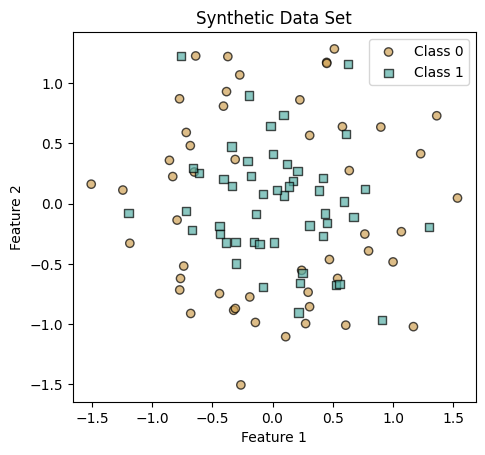

In [5]:
from sklearn.datasets import make_circles
import torch
import matplotlib.pyplot as plt

X, y = make_circles(n_samples=100, factor=0.5, noise=0.3, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
X = torch.cat([torch.ones(X.shape[0], 1), X], dim=1) # add bias term
y = torch.tensor(y, dtype=torch.float32)

def scatter_data(X, y, ax):
    markers = ['o', 's']
    for i in range(2):
        idx = (y.flatten() == i)
        ax.scatter(X[idx, 1], X[idx, 2], c = y.flatten()[idx], label=f'Class {i}', edgecolor='k', marker=markers[i],   cmap = 'BrBG', vmin = -0.5, vmax = 1.5, alpha = 0.7)

fig, ax = plt.subplots()
scatter_data(X, y, ax)


ax.set_aspect('equal')
ax.set_title('Synthetic Data Set')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
plt.show()

We previously implemented logistic regression like this:

In [2]:
class LogisticRegression:
    def __init__(self, n_features):
        self.W = torch.randn(n_features, 2, requires_grad=True)

    def forward(self, X):
        return torch.softmax(X @ self.W, dim=1)

To transition into more extensible code, we’re going to leverage torch’s `nn.Module` class, which provides a convenient way to define models with learnable parameters. Here’s how we can implement the same logistic regression model using `nn.Module`:

In [19]:
from torch import nn
class LogisticRegression(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    # initialize and store an abstract representation that reflects the idea of matrix multiplication
    self.layer1 = nn.Linear(n_features, 2) # linear layer, n features go in, 2 (logistic reg.) come out # W

  def forward(self, X):
    x1 = self.layer1(X)
    return torch.softmax(x1, dim = 1)

If we try this model on our sample data, we should expect to see the linear decision boundary that we get from logistic regression.

Let’s give this a shot using a standard training loop.

In [20]:
def train_model(model, X, y, n_epochs=2000):
    opt = torch.optim.SGD(model.parameters(), lr=1) # optimize all params of model
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(n_epochs):
        opt.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y.long())
        losses.append(loss.item())
        loss.backward()
        opt.step()
    return losses

model = LogisticRegression(n_features=X.shape[1])
losses= train_model(model, X, y)

In [21]:
def plot_decision_contours(model, ax, cmap = "BrBG"):
    x_min, x_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    y_min, y_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
    x = torch.linspace(x_min, x_max, 101)
    y = torch.linspace(y_min, y_max, 101)

    xx, yy = torch.meshgrid(x, y)
    grid_points = torch.cat([torch.ones(xx.shape[0], xx.shape[1], 1), xx.unsqueeze(-1), yy.unsqueeze(-1)], dim=-1)
    with torch.no_grad():
        pred = model(grid_points.reshape(-1, 3))
        pred = pred[:, 1].reshape(xx.shape) # probability of class 1
    ax.contourf(xx.numpy(), yy.numpy(), pred.numpy(), alpha=0.3, cmap = cmap, vmin = -0.5, vmax = 1.5, zorder = -100)
    ax.contour(xx.numpy(), yy.numpy(), pred.numpy(), levels=[0.5], colors='k', linewidths=1, zorder = -100, linestyles='--')

def plot_contours_and_scatter(model, X, y, ax):
    plot_decision_contours(model, ax)
    scatter_data(X, y, ax)
    ax.set_aspect('equal')
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.legend()

Figure 4: Decision boundary learned by logistic regression.

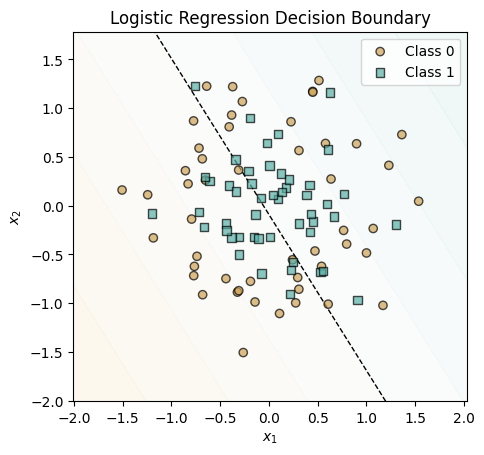

In [22]:
fig, ax = plt.subplots()
plot_contours_and_scatter(model, X, y, ax)
t = ax.set_title('Logistic Regression Decision Boundary')

Since we have not baked any nonlinear features into this model, the model simply uses a linear decision boundary with predictably poor results.

Now let’s try a model with multiple linear layers:

In [25]:
class DeepModelAttempt(nn.Module):
  def __init__(self, n_features, hidden_dim = 10, output_dim = 2): # hidden_dim is dimmension of the learned features
    super().__init__()
    self.layer1 = nn.Linear(n_features, hidden_dim)
    self.layer2 = nn.Linear(hidden_dim, output_dim)

  def forward(self, X):
    x1 = self.layer1(X)
    x1_ = torch.relu(x1)
    x2 = self.layer2(x1_)
    return torch.softmax(x2, dim=1)


Let’s fit this model to data, making sure to use plenty of hidden dimensions:

Figure 5: Decision boundary learned by a “deep” model with two linear layers but no nonlinear activation function.

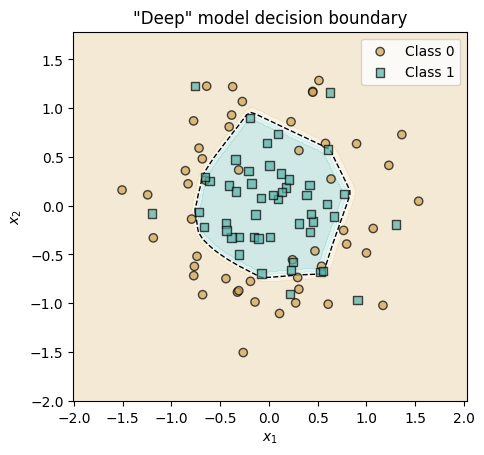

In [26]:
model = DeepModelAttempt(n_features=X.shape[1], hidden_dim=500, output_dim = 2)
losses = train_model(model, X, y, n_epochs = 2000)
fig, ax = plt.subplots()

plot_contours_and_scatter(model, X, y, ax)

t = ax.set_title('"Deep" model decision boundary')

Oh dear – our classifier has still learned a linear decision boundary. The reason is that we’ve forgotten something important: the nonlinear activation function between the first and second `Linear` layers. Between our two linear layers we’ve essentially performed the computation $\mathbf{s}= \mathbf{x}\mathbf{V}\mathbf{W}= \mathbf{x}(\mathbf{W}\mathbf{V})$, which we could have achieved with a single matrix multiplication. So, the model above is equivalent to logistic regression again.

To correctly implement our first deep learning model, we’ll add a nonlinear activation function between the two layers. Following historical precedent, we’ll refer to this model as the *multilayer perceptron* (MLP).

In [28]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden_dim=10, output_dim = 2):
        super().__init__()
        self.feature_layer = nn.Linear(n_features, hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, X):
        x1 = torch.relu(self.feature_layer(X))
        return torch.softmax(self.output_layer(x1), dim=1)

Let’s train this model and inspect it’s performance. We’ll use a total of 5 hidden features, which means that $\mathbf{V}\in \mathbb{R}^{n \times 5}$ and $\mathbf{W}\in \mathbb{R}^{5\times 2}$.

In [29]:
model = MLP(n_features=X.shape[1], hidden_dim=2, output_dim = 2)
losses = train_model(model, X, y, n_epochs = 2000)

Figure 6: Decision boundary learned by a multilayer perceptron with one hidden layer and two hidden features.

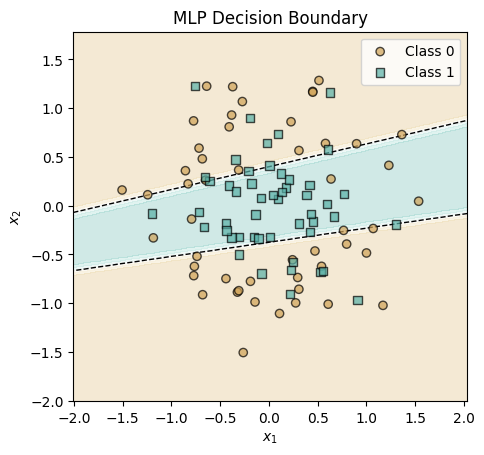

In [30]:
fig, ax = plt.subplots()
plot_contours_and_scatter(model, X, y, ax)
t = ax.set_title('MLP Decision Boundary')

With a hidden dimension of size 2, our model is already able to learn a nonlinear decision boundary. Let’s explore the impact of increasing the hidden dimension.

Figure 7: Decision boundaries learned by a multilayer perceptron with one hidden layer and varying hidden dimension sizes.

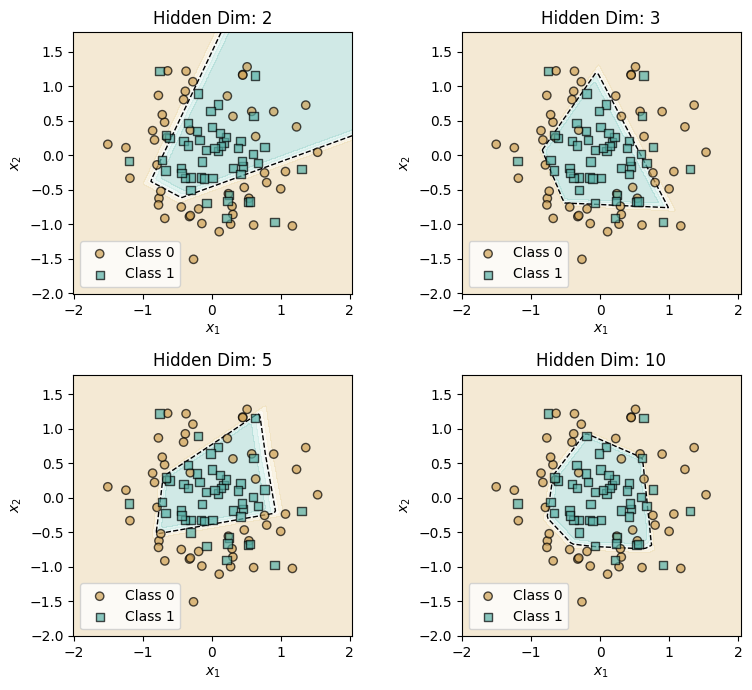

In [31]:
torch.manual_seed(12)

fig, ax = plt.subplots(2, 2, figsize=(8, 7))

for i, hidden_dim in enumerate([2, 3, 5, 10]):
    model = MLP(n_features=X.shape[1], hidden_dim=hidden_dim, output_dim = 2)
    losses = train_model(model, X, y, n_epochs = 2000)
    plot_contours_and_scatter(model, X, y, ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'Hidden Dim: {hidden_dim}')

plt.tight_layout()

As we increase the hidden dimension, the model develops a greater capacity to learn more complex decision boundaries, giving a relatively smoother decision boundary.

### Tuning Model Complexity

Increasing the hidden dimension size is one way to increase model complexity. Another way is to add more layers, again separated by nonlinear activation functions.

In [33]:
class DeeperMLP(nn.Module):
    def __init__(self, n_features, hidden_dim=10, output_dim = 2):
        super().__init__()
        self.feature_layer1 = nn.Linear(n_features, hidden_dim)
        self.feature_layer2 = nn.Linear(hidden_dim, hidden_dim) # each output dim must match next input dim.
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, X):
        x1 = torch.relu(self.feature_layer1(X))
        x2 = torch.relu(self.feature_layer2(x1))
        return torch.softmax(self.output_layer(x2), dim=1)

As usual, models which are excessively complex may begin to show visual signs of overfitting, although techniques like cross-validation should be used to provide a formal assessment.

Figure 8: Decision boundary learned by a multilayer perceptron with two layers and 50 hidden features in each layer.

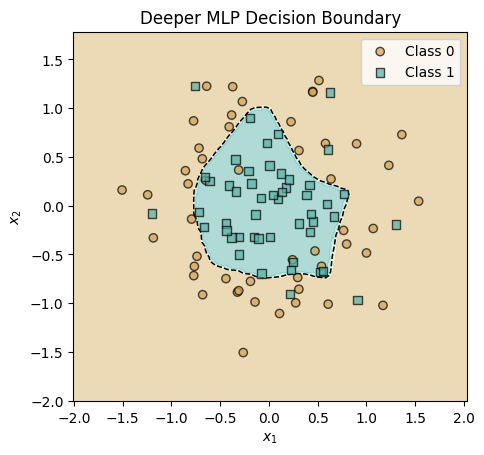

In [34]:
torch.manual_seed(12345)
model = DeeperMLP(n_features=X.shape[1], hidden_dim=50, output_dim = 2)
losses = train_model(model, X, y, n_epochs = 5000)
fig, ax = plt.subplots()
plot_contours_and_scatter(model, X, y, ax)
plot_decision_contours(model, ax)
ax.set_title('Deeper MLP Decision Boundary')
plt.show()

### Inspecting Learned Features

Recall that our motivation for deep learning was to *learn the features* rather than specifying them ahead of time. What features have we learned?

Because of the composable, layered structure of our model, it’s relatively simple to see the outputs of each layer on the data: we just need to call the relevant layer. For example:

In [35]:
with torch.no_grad():
    learned_features1 = model.feature_layer1(X)
    learned_features2 = model.feature_layer2(torch.relu(learned_features1))

learned_features1.shape, learned_features2.shape

(torch.Size([100, 50]), torch.Size([100, 50]))

In the code block below, we call each of the two layers of our model on grid so that we can visualize the feature representations.

Figure 9: Visualization of the decision boundary learned by the multilayer perceptron with two hidden layers, alongside one learned feature from each of the two layers.

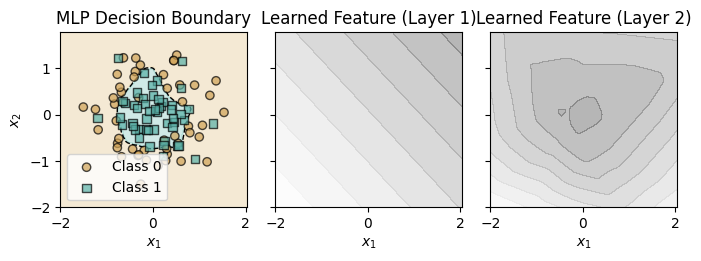

In [39]:
fig, axarr = plt.subplots(1, 3, figsize=(7, 2.7), sharex=True, sharey=True)

ax = axarr[0]

plot_contours_and_scatter(model, X, y, ax)

ax.set_title('MLP Decision Boundary')

x_min, x_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
y_min, y_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
x_grid = torch.linspace(x_min, x_max, 101)
y_grid = torch.linspace(y_min, y_max, 101)

xx, yy = torch.meshgrid(x_grid, y_grid)
grid_points = torch.cat([torch.ones(xx.shape[0], xx.shape[1], 1), xx.unsqueeze(-1), yy.unsqueeze(-1)], dim=-1)

with torch.no_grad():
    learned_features1 = model.feature_layer1(grid_points)
    learned_features2 = model.feature_layer2(torch.relu(learned_features1))

ax = axarr[1]
ax.contourf(xx.numpy(), yy.numpy(), learned_features1[:, :, 0].reshape(xx.shape).numpy(), alpha=0.3, cmap = 'Greys')
ax.grid(False)
ax.set_title('Learned Feature (Layer 1)')
ax.set_aspect('equal')
ax.set_xlabel(r"$x_1$")

ax = axarr[2]
axarr[2].contourf(xx.numpy(), yy.numpy(), learned_features2[:, :, 0].reshape(xx.shape).numpy(), alpha=0.3, cmap = 'Greys')
axarr[2].grid(False)
ax.set_title('Learned Feature (Layer 2)')
ax.set_aspect('equal')
ax.set_xlabel(r"$x_1$")


plt.tight_layout()

The first layer is able to learn only linear features, which individually are of little use. However, by combining many linear features, the second layer is able to learn a nonlinear feature that roughly describes the radial structure of the data set.